# SDV & VARIANCE

In [26]:
import xarray as xr
import numpy as np
import pandas as pd
from cartopy.util import add_cyclic_point
import sys
import os
import seaborn as 
import matplotlib.lines as mlines
import intake
from xeofs.single import EOF 
import xeofs as xe
from scipy.stats import linregress
from scipy import stats
from dask import delayed
from IPython.display import display, HTML
import imageio
#from joblib import Parallel, delayed
import matplotlib.dates as mdates
import intake
#from DV8_ext_opening import *
from DV8_extremes import *
#DV8_functions(1) packages
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FFMpegWriter
from matplotlib import animation, rc
from IPython.display import HTML
#my functions:


import matplotlib.colors as mcolors

from tempfile import TemporaryDirectory
from getpass import getuser
from pathlib import Path
import dask
from dask.distributed import Client, LocalCluster
import bokeh
import subprocess
import re

import warnings
#warnings.filterwarnings('ignore')
scratch_dir = Path('/scratch') / getuser()[0] / getuser()

In [15]:


dask.config.config.get('distributed').get('dashboard').update({'link':'{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'})
cluster = LocalCluster(n_workers=32,threads_per_worker=1)
client = Client(cluster)
client

/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37737 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/b382616/levante-spawner-advanced//proxy/37737/status,
Dashboard: /user/b382616/levante-spawner-advanced//proxy/37737/status,Workers: 32
Total threads: 32,Total memory: 250.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33897,Workers: 0
Dashboard: /user/b382616/levante-spawner-advanced//proxy/37737/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40659,Total threads: 1
Dashboard: /user/b382616/levante-spawner-advanced//proxy/43797/status,Memory: 7.81 GiB
Nanny: tcp://127.0.0.1:36831,


2026-01-11 16:54:47,389 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:46377 (pid=3191081) exceeded 95% memory budget. Restarting...
2026-01-11 16:54:49,000 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:46377' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('rechunk-split-rechunk-merge-7904b15fc118ce874836075117fa43b9', 7, 0, 0), ('rechunk-merge-c2bea764ba3b2512152522f8d2eab702', 14, 0, 0), ('getitem-24f8074149f53f9e5f8303e9c44a39b6', 4, 0, 0), ('rechunk-merge-7904b15fc118ce874836075117fa43b9', 18, 0, 0), ('rechunk-merge-c2bea764ba3b2512152522f8d2eab702', 18, 0, 0), ('rechunk-merge-7904b15fc118ce874836075117fa43b9', 15, 0, 0), ('rechunk-split-rechunk-merge-7904b15fc118ce874836075117fa43b9', 14, 0, 0), ('getitem-24f8074149f53f9e5f8303e9c44a39b6', 2, 0, 0), ('rechunk-merge-c2bea764ba3b2512152522f8d2eab702', 15, 0, 0)} (stimulus_id='handle-worker-cleanup-1768146889.0005913')
2026-01-11 16:54:50,007 - distribu

# LOAD DATA
### Only take latitudes between 50°S and 70°N, to retain only ice-free oceans. To make sure no sea ice appears in these latitudes we apply SSTA=SSTA.where(sst>-1.7) for all anomalies. Gridcells with sea ice are defined in OSTIA,ICON and IFS-FESOM as an SST value of ~-1.75, by applying the where condition we make sure to only take ice free times and grid-cells without throwing out entire areas, but only the times and places where sea ice appears.
### Convert ICON and IFS-FESOM longitudes from 0->360 to -180->180

In [16]:

def lon_180w_180e(ds_sice: xr.DataArray):
    ds_sice = (
        ds_sice
        .assign_coords(lon=lambda x: (x.lon - 180) % 360 - 180)
        .sortby('lon'))

    return ds_sice

In [17]:
#SST

# OSTIA
filename='/scratch/b/b382615/mhws/ostia.zarr' 
sst = xr.open_zarr(str(filename), chunks={'time':150, 'lat':-1, 'lon':-1}).sst
sst=sst.sel(lat=slice(-50, 70))
sst=sst-273.15

# ICON HISTORICAL
cat = intake.open_catalog("https://raw.githubusercontent.com/eerie-project/intake_catalogues/main/eerie.yaml")
dat = cat['dkrz.disk.model-output.icon-esm-er.hist-1950.v20240618.ocean.gr025']
sst_ic = dat['2d_daily_mean'](chunks={}).to_dask().to.isel(depth=0).drop_vars('depth').chunk({'time':150, 'lat':-1, 'lon':-1})
sst_ic=sst_ic.sel(lat=slice(-50, 70))


# IFS FESOM
cat = intake.open_catalog("https://raw.githubusercontent.com/eerie-project/intake_catalogues/main/eerie.yaml")
dat = cat['dkrz.disk.model-output.ifs-fesom2-sr.hist-1950.v20240304.ocean.gr025']#.icon-esm-er.hist-1950.v20240618.ocean.gr025']
sst_f = dat['2D_daily_avg_1950-2014'].to_dask().avg_tos.isel(depth=0).drop_vars('depth').chunk({'time':150, 'lat':-1, 'lon':-1})
sst_f=sst_f.sel(lat=slice(-50, 70))




#IFS NEMO
filename='/home/b/b382616/scratch/ifsnemo_hist_sst.zarr' 
sst_n = xr.open_zarr(str(filename), chunks={'time':30, 'lat':-1, 'lon':-1})
sst_n=sst_n.tos.chunk({'time':150, 'lat':-1, 'lon':-1})
sst_n=sst_n.sel(lat=slice(-50, 70))



/tmp/ipykernel_3181396/1409816785.py:27: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  sst_n = xr.open_zarr(str(filename), chunks={'time':30, 'lat':-1, 'lon':-1})


In [18]:
# HADGEM LL
sst_LL = xr.open_dataset(
    '/home/b/b382616/scratch/mhws/hadgem/input_data/LL/toscon_nemo_u-da156_1d_19700101-20150101_grid-025.nc',
    chunks={'time': 150, 'lat': -1, 'lon': -1}  # Chunk by year, full spatial dimensions
)
sst_LL=sst_LL['toscon'].sel(lat=slice(-50, 70))


# HADGEM MM
sst_MM = xr.open_dataset(
    '/home/b/b382616/scratch/mhws/hadgem/input_data/MM/toscon_nemo_u-dc396_1d_19700101-20150101_grid-025.nc',
    chunks={'time': 150, 'lat': -1, 'lon': -1}  # Chunk by year, full spatial dimensions
)
sst_MM=sst_MM['toscon'].sel(lat=slice(-50, 70))


# HADGEM HH
sst_HH = xr.open_dataset(
    '/home/b/b382616/scratch/mhws/hadgem/input_data/HH/toscon_nemo_u-di356_1d_19700101-20150101_grid-025.nc',
    chunks={'time': 150, 'lat': -1, 'lon': -1}  # Chunk by year, full spatial dimensions
)
sst_HH=sst_HH['toscon'].sel(lat=slice(-50, 70))

            

/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'toscon' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'toscon' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'toscon' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [19]:
# FIXED BASELINES


# FIXED BASELINES

# OSTIA ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'OSTIA_pre_1982_2014_FixedDetrend_hob_oct25.zarr'
chunks={'time': 400, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
ds = xr.open_zarr(str(file_name), chunks=chunks)
ds = ds.sel(lat=slice(-50, 70))
ossta=ds['dat_anomaly']
sst=sst.sel(time=slice((ossta.time[0].values),str(ossta.time[-1].values))) #making sure SST time matches SSTA time before masking the sea ice
ossta=ossta.where(sst>-1.7) #remove from anomalies places and times where there is sea ice



# ICON HIST ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'ICONhist_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
i_ds = xr.open_zarr(str(file_name), chunks=chunks)
i_ds=lon_180w_180e(i_ds)
sst_ic=lon_180w_180e(sst_ic)
i_ds = i_ds.sel(lat=slice(-50, 70))
issta=i_ds['dat_anomaly']
sst_ic=sst_ic.sel(time=slice(str(issta.time[0].values),str(issta.time[-1].values)))
# Now apply the sea ice mask
issta = issta.where(sst_ic > -1.7)



# IFS-FESOM ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'IfsFesom_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
f_ds = xr.open_zarr(str(file_name), chunks=chunks)
f_ds=lon_180w_180e(f_ds)
sst_f=lon_180w_180e(sst_f)
f_ds = f_ds.sel(lat=slice(-50, 70))
fssta=f_ds['dat_anomaly']
sst_f=sst_f.sel(time=slice((fssta.time[0].values),str(fssta.time[-1].values)))
# Now apply the sea ice mask
fssta = fssta.where(sst_f > -1.7)





# IFS-NEMO ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser()  / "mhws" / "IfsNemo_pre_1982_2014_FixedDetrend_hob_jan26.zarr"
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
n_ds = xr.open_zarr(str(file_name), chunks=chunks)
n_ds=lon_180w_180e(n_ds)
sst_n=lon_180w_180e(sst_n)
n_ds = n_ds.sel(lat=slice(-50, 70))
nssta=n_ds['dat_anomaly']
sst_n=sst_n.sel(time=slice((nssta.time[0].values),str(nssta.time[-1].values)))
# Now apply the sea ice mask
nssta = nssta.where(sst_n > -1.7)

In [20]:


# HADGEM LL ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'LL'/'HadGEM3-LL_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
LL_ds = xr.open_zarr(str(file_name), chunks=chunks)
LL_ds=lon_180w_180e(LL_ds)
sst_LL=lon_180w_180e(sst_LL)
LL_ds = LL_ds.sel(lat=slice(-50, 70))
LLssta=LL_ds['dat_anomaly']
sst_LL=sst_LL.sel(time=slice((LLssta.time[0].values),str(LLssta.time[-1].values)))
# Now apply the sea ice mask
LLssta = LLssta.where(sst_LL > -1.7)

# HADGEM MM ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'MM'/'HadGEM3-MM_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
MM_ds = xr.open_zarr(str(file_name), chunks=chunks)
MM_ds=lon_180w_180e(MM_ds)
sst_MM=lon_180w_180e(sst_MM)
MM_ds = MM_ds.sel(lat=slice(-50, 70))
MMssta=MM_ds['dat_anomaly']
sst_MM=sst_MM.sel(time=slice((MMssta.time[0].values),str(MMssta.time[-1].values)))
# Now apply the sea ice mask
MMssta = MMssta.where(sst_MM > -1.7)


# HADGEM HH ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'HH'/'HadGEM3-HH_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
HH_ds = xr.open_zarr(str(file_name), chunks=chunks)
HH_ds=lon_180w_180e(HH_ds)
sst_HH=lon_180w_180e(sst_HH)
HH_ds = HH_ds.sel(lat=slice(-50, 70))
HHssta=HH_ds['dat_anomaly']
sst_HH=sst_HH.sel(time=slice((HHssta.time[0].values),str(HHssta.time[-1].values)))
# Now apply the sea ice mask
HHssta = HHssta.where(sst_HH> -1.7)


/tmp/ipykernel_3181396/481346273.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  LL_ds = xr.open_zarr(str(file_name), chunks=chunks)
/tmp/ipykernel_3181396/481346273.py:16: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  MM_ds = xr.open_zarr(str(file_name), chunks=chunks)
/tmp/ipykernel_3181396/481346273.py:29: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  HH_ds = xr.open_zarr(str(file_name), chunks=chunks)


# SDV

In [21]:
models_sst = {
    'OSTIA': sst,     
    'ICON': sst_ic,      
    'IFS-FESOM': sst_f,
    'IFS-NEMO': sst_n,
    'HadGEM3-HH': sst_HH
}
models_sst_lowres = {
    'HadGEM3-MM': sst_MM,
    'HadGEM3-LL': sst_LL
}

models_ssta = {
    'OSTIA': ossta,     
    'ICON': issta,     
    'IFS-FESOM': fssta,
    'IFS-NEMO': nssta,
    'HadGEM3-HH': HHssta
}

models_ssta_lowres = {
    'HadGEM3-MM': MMssta,
    'HadGEM3-LL': LLssta
}

In [9]:
#SST

# Create a dictionary to hold the results
sdv_results = {}

# Combine your source dictionaries
all_sst_raw = {**models_sst, **models_sst_lowres}

print("Computing Standard Deviations...")
for name, data in all_sst_raw.items():
    # .compute() ensures the calculation happens now if using Dask
    sdv_results[name] = data.std(dim='time').compute()
    print(f"Done: {name}")

Computing Standard Deviations...


/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Done: OSTIA


/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Done: ICON


...

2026-01-11 14:57:56,261 - distributed.worker.memory - WARNING - Worker is at 81% memory usage. Pausing worker.  Process memory: 6.40 GiB -- Worker memory limit: 7.81 GiB
2026-01-11 14:57:56,821 - distributed.worker.memory - WARNING - Worker is at 48% memory usage. Resuming worker. Process memory: 3.82 GiB -- Worker memory limit: 7.81 GiB
2026-01-11 14:57:58,634 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 6.27 GiB -- Worker memory limit: 7.81 GiB
2026-01-11 14:57:59,335 - distributed.worker.memory - WARNING - Worker is at 43% memory usage. Resuming worker. Process memory: 3.37 GiB -- Worker memory limit: 7.81 GiB
2026-01-11 14:58:10,900 - distributed.worker.memory - WARNING - Worker is at 90% memory usage. Pausing worker.  Process memory: 7.08 GiB -- Worker memory limit: 7.81 GiB
2026-01-11 14:58:11,549 - distributed.worker - ERROR - failed during get data with tcp://127.0.0.1:33691 -> tcp://127.0.0.1:33397
Traceback (most rece

Done: HadGEM3-HH


/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Done: HadGEM3-MM
Done: HadGEM3-LL


/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


<>:29: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:29: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_3181396/3543448060.py:29: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  cbar.set_label('SST SDV ($^\circ C$)', fontsize=12)


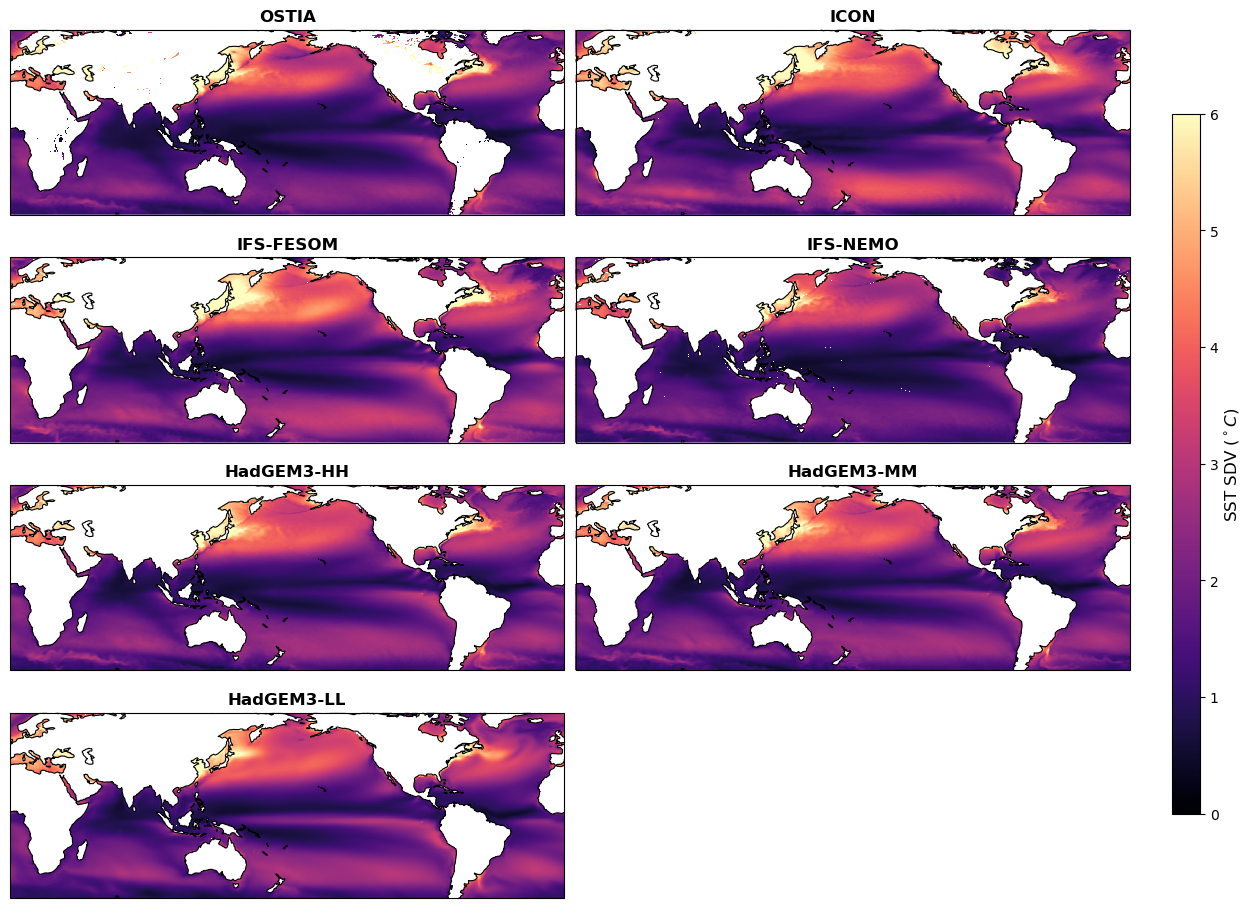

In [10]:

# 1. Setup figure (Wider and shorter helps close vertical gaps)
fig, axes = plt.subplots(4, 2, figsize=(14, 10), 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
axes = axes.flatten()

# 2. Adjust spacing - hspace controls vertical gaps
fig.subplots_adjust(wspace=0.02, hspace=0.05, left=0.05, right=0.85, top=0.95, bottom=0.05)

im = None

for i, (name, sdv_data) in enumerate(sdv_results.items()):
    ax = axes[i]
    
    # Plot using the pre-computed sdv_data
    im = sdv_data.plot(ax=ax, transform=ccrs.PlateCarree(), 
                       cmap='magma', vmin=0, vmax=6, robust=True, 
                       add_colorbar=False)
    
    ax.coastlines(resolution='110m', linewidth=0.8)
    ax.set_title(name, fontsize=12, fontweight='bold')

# 3. Handle the empty 8th subplot
fig.delaxes(axes[7])

# 4. Add the common colorbar
# Using fig.add_axes gives you precise control over placement
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('SST SDV ($^\circ C$)', fontsize=12)

plt.show()

In [22]:
#SSTA

# Create a dictionary to hold the results
sdv_results_ssta = {}

# Combine your source dictionaries
all_ssta_raw = {**models_ssta, **models_ssta_lowres}

print("Computing Standard Deviations...")
for name, data in all_ssta_raw.items():
    # .compute() ensures the calculation happens now if using Dask
    sdv_results_ssta[name] = data.std(dim='time').compute()
    print(f"Done: {name}")

Computing Standard Deviations...


2026-01-11 16:54:49,045 - distributed.nanny - WARNING - Restarting worker
2026-01-11 16:54:51,331 - distributed.nanny - WARNING - Restarting worker
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Done: OSTIA


/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/dask/array/numpy_compat.py:58: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Done: ICON


...

Done: HadGEM3-HH


2026-01-11 17:03:06,369 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 5.37 GiB -- Worker memory limit: 7.81 GiB
2026-01-11 17:03:10,878 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:33299
Traceback (most recent call last):
  File "/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/d

Done: HadGEM3-MM


2026-01-11 17:07:13,765 - distributed.nanny - WARNING - Restarting worker


Done: HadGEM3-LL


<>:29: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:29: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_3181396/2502809327.py:29: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  cbar.set_label('SSTA SDV ($^\circ C$)', fontsize=12)


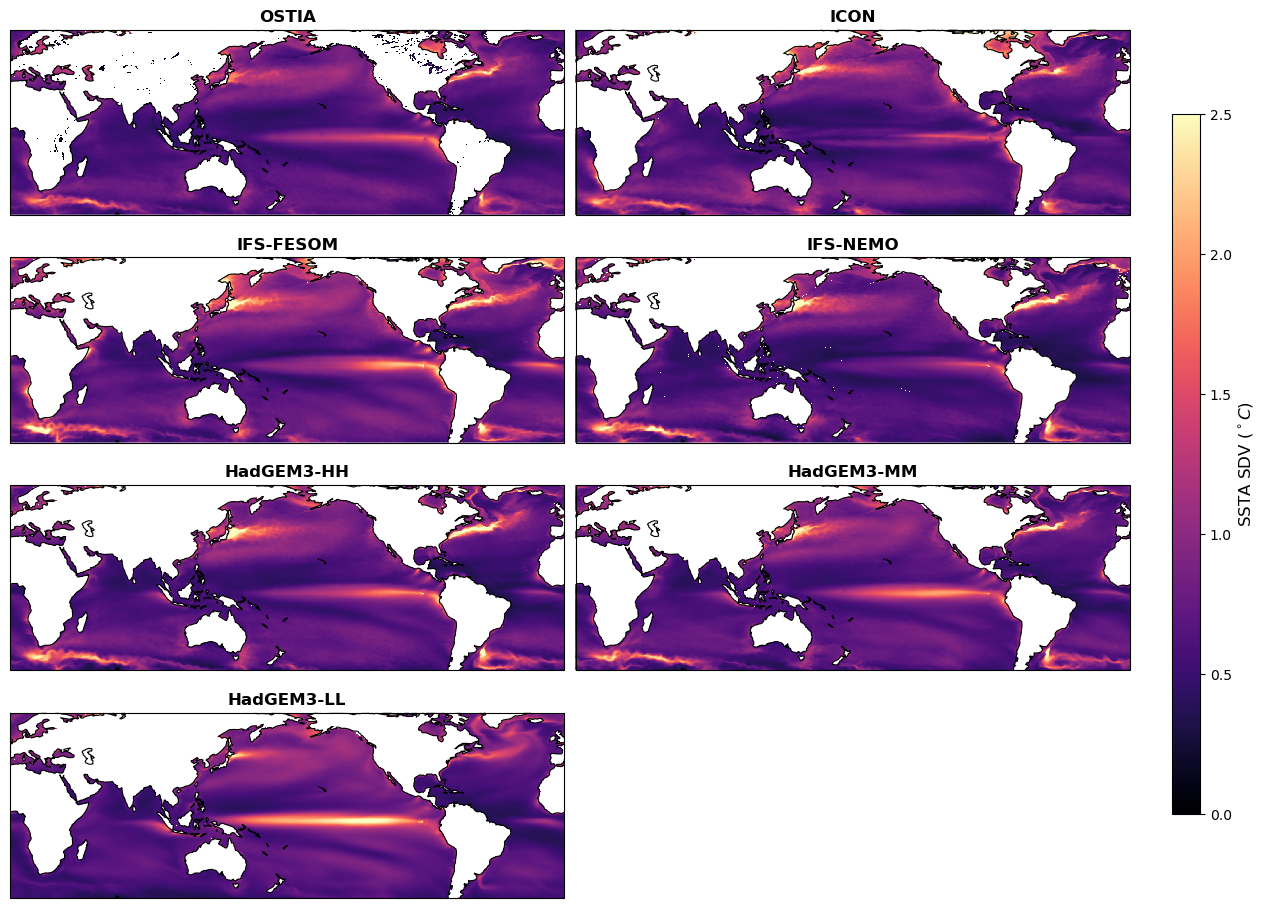

In [23]:

# 1. Setup figure (Wider and shorter helps close vertical gaps)
fig, axes = plt.subplots(4, 2, figsize=(14, 10), 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
axes = axes.flatten()

# 2. Adjust spacing - hspace controls vertical gaps
fig.subplots_adjust(wspace=0.02, hspace=0.05, left=0.05, right=0.85, top=0.95, bottom=0.05)

im = None

for i, (name, sdv_data) in enumerate(sdv_results_ssta.items()):
    ax = axes[i]
    
    # Plot using the pre-computed sdv_data
    im = sdv_data.plot(ax=ax, transform=ccrs.PlateCarree(), 
                       cmap='magma', vmin=0, vmax=2.5, robust=True, 
                       add_colorbar=False)
    
    ax.coastlines(resolution='110m', linewidth=0.8)
    ax.set_title(name, fontsize=12, fontweight='bold')

# 3. Handle the empty 8th subplot
fig.delaxes(axes[7])

# 4. Add the common colorbar
# Using fig.add_axes gives you precise control over placement
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('SSTA SDV ($^\circ C$)', fontsize=12)

plt.show()

# MULTI MODEL MEAN

In [ ]:
#SSTA

# Create a dictionary to hold the results
sdv_results_ssta = {}

# Combine your source dictionaries
all_ssta_raw = {**models_ssta, **models_ssta_lowres}

print("Computing Standard Deviations...")
for name, data in all_ssta_raw.items():
    # .compute() ensures the calculation happens now if using Dask
    sdv_results_ssta[name] = data.std(dim='time').compute()
    print(f"Done: {name}")

In [48]:
#INTERPOLATE TO OSTIA GRID


# 1. Define high-res list and reference grid
high_res_models = ['ICON', 'IFS-FESOM', 'IFS-NEMO', 'HadGEM3-HH']
low_res_models = [  'HadGEM3-MM','HadGEM3-LL']
ref_sdv = sdv_results_ssta['OSTIA']

sdv_anomalies = []
for name in high_res_models:
    print(f"Aligning {name}...")
    # Interp to OSTIA grid
    aligned = sdv_results_ssta[name].interp_like(ref_sdv, method='linear')
    # Calculate difference in SDV (Model SDV - OSTIA SDV)
    diff = (aligned - ref_sdv).compute()
    sdv_anomalies.append(diff)

# 2. Combine into a single DataArray
sdv_bias_ds = xr.concat(sdv_anomalies, dim='model')
mmm_sdv_bias = sdv_bias_ds.mean(dim='model').sortby('lon')

# 3. Agreement Logic (Where models agree on the sign of the SDV bias)
pos_count = (sdv_bias_ds > 0).sum(dim='model')
neg_count = (sdv_bias_ds < 0).sum(dim='model')
sdv_agreement = xr.where(pos_count >= neg_count, pos_count, neg_count) / len(high_res_models)
sdv_agreement = sdv_agreement.sortby('lon')

Aligning ICON...
Aligning IFS-FESOM...
Aligning IFS-NEMO...
Aligning HadGEM3-HH...


<>:34: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:34: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_3181396/1104142421.py:34: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  plt.colorbar(im, label='SDV Bias [$^\circ C$]', shrink=0.5, pad=0.02)


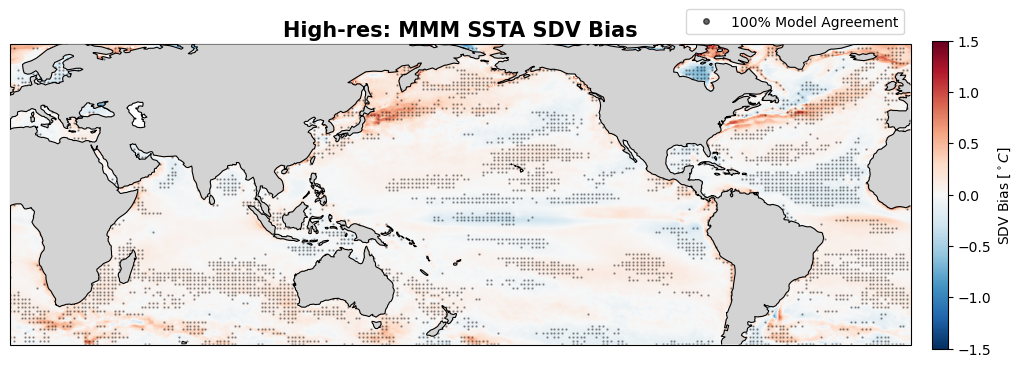

In [49]:


# 1. Prepare the figure and axis
plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

# 2. Plot MMM Bias
# .plot() handles the dateline seam automatically
im = mmm_sdv_bias.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r', 
    vmin=-1.5, vmax=1.5,
    add_colorbar=False,
    zorder=1
)

# 3. Stippling
skip = 6
stipple_data = sdv_agreement.where(mmm_sdv_bias.notnull()).isel(
    lat=slice(None, None, skip), 
    lon=slice(None, None, skip)
)
lon_mesh, lat_mesh = np.meshgrid(stipple_data.lon, stipple_data.lat)
stipple_mask = stipple_data.values == 1.0

ax.scatter(
    lon_mesh[stipple_mask], 
    lat_mesh[stipple_mask], 
    color='black', marker='.', s=1.5, alpha=0.4, 
    transform=ccrs.PlateCarree(),
    zorder=4
)

# 4. Formatting
plt.colorbar(im, label='SDV Bias [$^\circ C$]', shrink=0.5, pad=0.02)

# 5. Legend to the right of the title
stipple_proxy = mlines.Line2D([], [], color='black', marker='.', linestyle='None',
                              markersize=8, alpha=0.6, label='100% Model Agreement')

# (1.0, 1.01) puts it at the top right edge, slightly above the axis line
ax.legend(handles=[stipple_proxy], 
          loc='lower right', 
          bbox_to_anchor=(1.0, 1.01), 
          frameon=True, 
          fontsize=10)

ax.set_title('High-res: MMM SSTA SDV Bias', loc='center', fontsize=15, fontweight='bold')

# Geographic features & Extent
ax.set_extent([-180, 180, -50, 70], crs=ccrs.PlateCarree())
ax.coastlines(resolution='110m', linewidth=0.8, zorder=5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)

plt.show()

# VARIANCE

In [ ]:


# 1. Calculate variance (remains lazy until plotting/computing)
sst_var = sst.var(dim='time')

# 2. Create the figure and map
plt.figure(figsize=(15, 8))

# Define the display projection centered on the Pacific (180°)
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

# 3. Plot the data
# transform=ccrs.PlateCarree() tells Cartopy the data itself is in standard +/-180 lon
im = sst_var.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(), 
    cmap='RdYlBu_r', 
    robust=True,
    add_colorbar=True,
    cbar_kwargs={'label': 'SST Variance ($^\circ C^2$)', 'shrink': 0.8}
)

# 4. Add map details
ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor='lightgray') # Keeps the land clean

plt.title("SST Variance", fontsize=14)
plt.show()